In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [2]:
#importing the dataset which is in csv file
data = pd.read_csv('../Dataset/loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


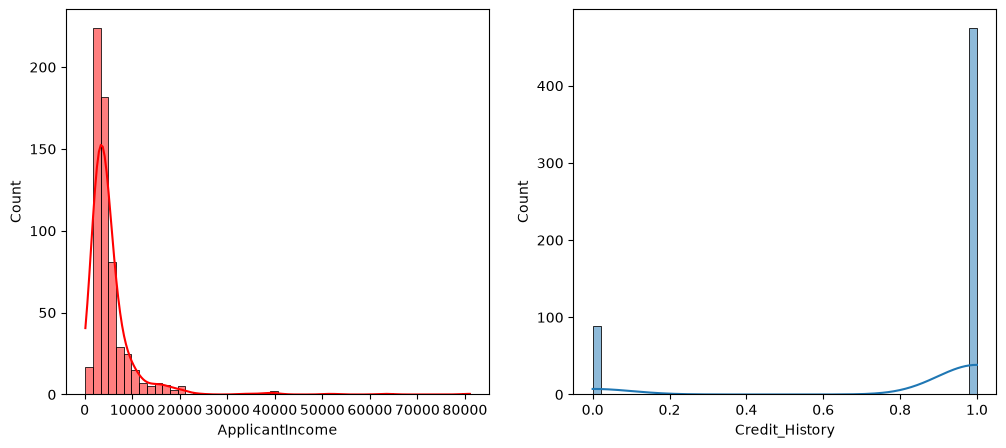

In [3]:
# Plotting using histplot
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data['ApplicantIncome'], color='red', kde=True)

plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)

plt.show()

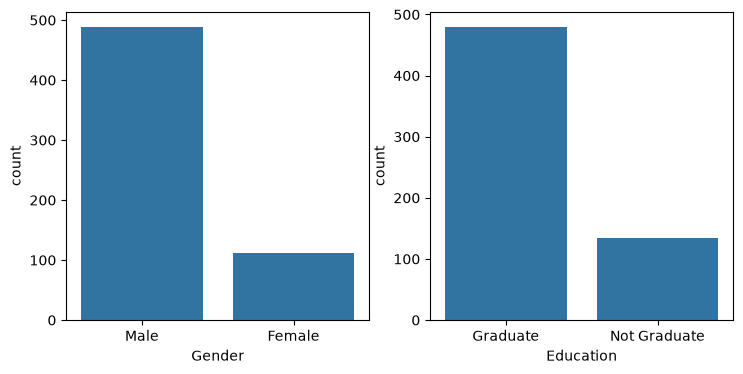

In [4]:
#plotting the count plot
plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
sns.countplot(data=data, x='Gender')

plt.subplot(1,4,2)
sns.countplot(data=data, x='Education')

plt.show()

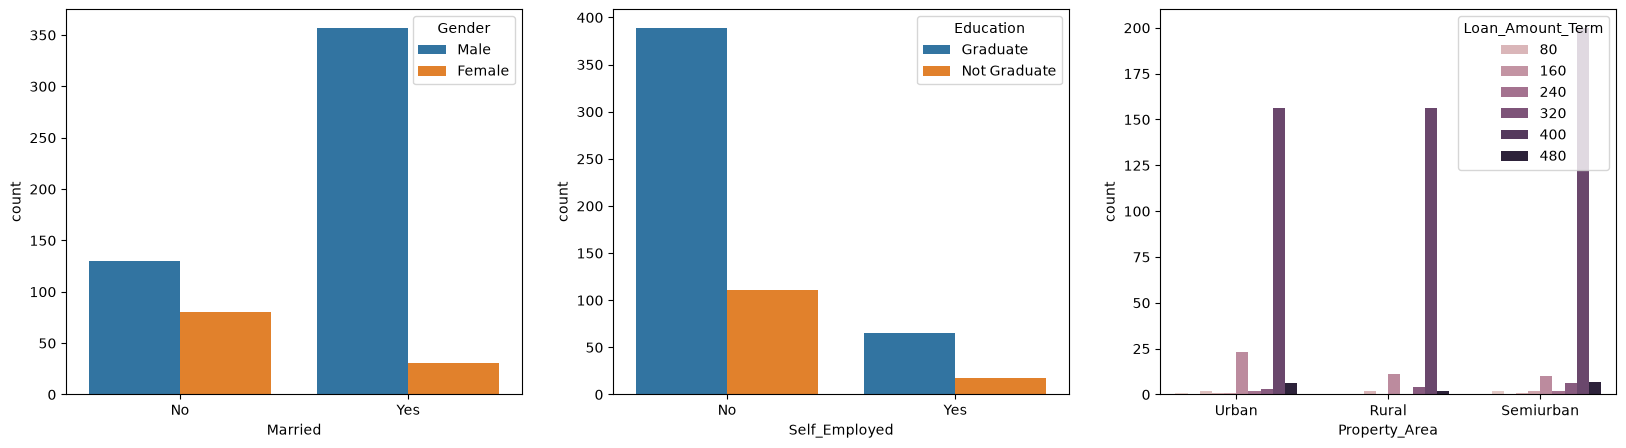

In [5]:
#visualising two columns againist each other
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')

plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')

plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

plt.show()

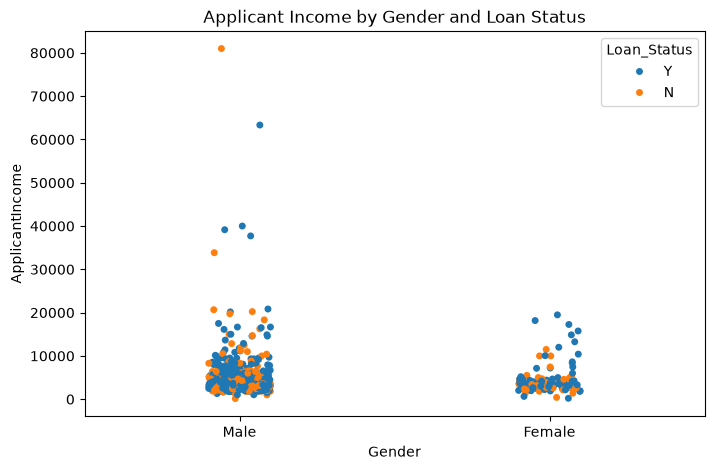

In [6]:


plt.figure(figsize=(8,5))

sns.stripplot(
    data=data,
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    jitter=True
)

plt.title("Applicant Income by Gender and Loan Status")
plt.show()

In [7]:
try:
    import jupyterthemes as jt
    get_ipython().system('jt -t onedork')
except:
    pass

In [8]:
data['Gender'] = data['Gender'].map({'Female':1,'Male':0})
data['Property_Area'] = data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})
data['Married'] = data['Married'].map({'Yes':1,'No':0})
data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})
data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

In [9]:
# Handling categorical feature Gender

data['Gender'] = data['Gender'].map({1:1,0:0})
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,No,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1


In [10]:
data['Property_Area'] = data['Property_Area'].map({2:2,1:1,0:0})

In [11]:
# finding the sum of null values in each column

data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

In [13]:
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

In [14]:
# replacing + with space for filling the nan values

data['Dependents'] = data['Dependents'].str.replace('+','', regex=False)

In [15]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

In [16]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

In [17]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])

In [18]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [19]:
# getting the total info of the data after performing categorical to numerical
# and replacing missing values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    float64
 2   Married            614 non-null    float64
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(6), int64(4), str(3)
memory usage: 62.5 KB


In [20]:
# changing the datatype of each float column to int

data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].map({'Yes':1,'No':0})

data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0]).astype('int64')
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0]).astype('int64')

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            614 non-null    str  
 1   Gender             614 non-null    int64
 2   Married            614 non-null    int64
 3   Dependents         614 non-null    int64
 4   Education          614 non-null    int64
 5   Self_Employed      614 non-null    int64
 6   ApplicantIncome    614 non-null    int64
 7   CoapplicantIncome  614 non-null    int64
 8   LoanAmount         614 non-null    int64
 9   Loan_Amount_Term   614 non-null    int64
 10  Credit_History     614 non-null    int64
 11  Property_Area      614 non-null    int64
 12  Loan_Status        614 non-null    int64
dtypes: int64(12), str(1)
memory usage: 62.5 KB


In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [23]:
# Drop Loan_ID column
data = data.drop('Loan_ID', axis=1)

In [24]:
x = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

In [25]:
# creating a new x and y variables for the balanced set

x_bal, y_bal = smote.fit_resample(x, y)

In [26]:
# printing the values of y before balancing the data and after

print(y.value_counts())
print(y_bal.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [27]:
names = x_bal.columns

In [28]:
# performing feature Scaling operation using standard scaler on X part of the dataset because
# there different type of values in the columns

sc = StandardScaler()

x_bal = sc.fit_transform(x_bal)

In [29]:
x_bal = pd.DataFrame(x_bal, columns=names)

In [30]:
# splitting the dataset in train and test on balanced dataset

X_train, X_test, y_train, y_test = train_test_split(
    x_bal,
    y_bal,
    test_size=0.33,
    random_state=42
)

In [31]:
X_train.shape

(565, 11)

In [32]:
X_test.shape

(279, 11)

In [33]:
# importing and building the Decision Tree model

def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy :", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Test Accuracy  :", accuracy_score(y_test, y_pred))

    return model

In [34]:
# printing the train accuracy and test accuracy respectively

dt_model = decisionTree(X_train, X_test, y_train, y_test)

Train Accuracy : 1.0
Test Accuracy  : 0.7741935483870968


In [35]:
# importing and building the Random Forest model

def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy :", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Test Accuracy  :", accuracy_score(y_test, y_pred))

    return model

In [36]:
# printing the train accuracy and test accuracy respectively

rf_model = RandomForest(X_train, X_test, y_train, y_test)

Train Accuracy : 1.0
Test Accuracy  : 0.7849462365591398


In [37]:
# importing and building the KNN model

def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy :", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Test Accuracy  :", accuracy_score(y_test, y_pred))

    return model

In [38]:
# printing the train accuracy and test accuracy respectively

knn_model = KNN(X_train, X_test, y_train, y_test)

Train Accuracy : 0.856637168141593
Test Accuracy  : 0.7491039426523297


In [39]:
# importing and building the XG Boost model

def XGB(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy :", accuracy_score(y_train, y_tr))

    y_pred = model.predict(X_test)
    print("Test Accuracy  :", accuracy_score(y_test, y_pred))

    return model

In [40]:
# printing the train accuracy and test accuracy respectively

xgb_model = XGB(X_train, X_test, y_train, y_test)

Train Accuracy : 0.9256637168141593
Test Accuracy  : 0.7921146953405018


In [41]:
# saving the Random Forest model using pickle function

pickle.dump(rf_model, open('rdf.pkl', 'wb'))

In [42]:
sc = StandardScaler()
x_bal = sc.fit_transform(x_bal)

In [43]:
# saving the scaler using pickle

pickle.dump(sc, open('scale1.pkl', 'wb'))

In [44]:
# saving the Random Forest model

pickle.dump(rf_model, open('rdf.pkl', 'wb'))